# Week 7, Day 25 — Introduction to Computer Vision & CNNs
**Dataset:** CIFAR-10 — 60,000 real photographs (cats, dogs, cars, planes etc.)  


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
#print("All libraries imported successfully!")

TensorFlow version: 2.20.0


## Load and Explore the Dataset
We are using **CIFAR-10** — a famous real-world image dataset.  
It contains 60,000 real photographs across 10 classes.

In [2]:
# Load CIFAR-10 — real photographs, downloads automatically the first time
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# The 10 classes in the dataset
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Understand what we loaded
print("Training images shape :", x_train.shape)
# (50000, 32, 32, 3) means:
# 50,000 images | 32 pixels tall | 32 pixels wide | 3 colour channels (RGB)

print("Test images shape     :", x_test.shape)
print("Pixel value range     :", x_train.min(), "to", x_train.max())
print("Classes               :", class_names)

Training images shape : (50000, 32, 32, 3)
Test images shape     : (10000, 32, 32, 3)
Pixel value range     : 0 to 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


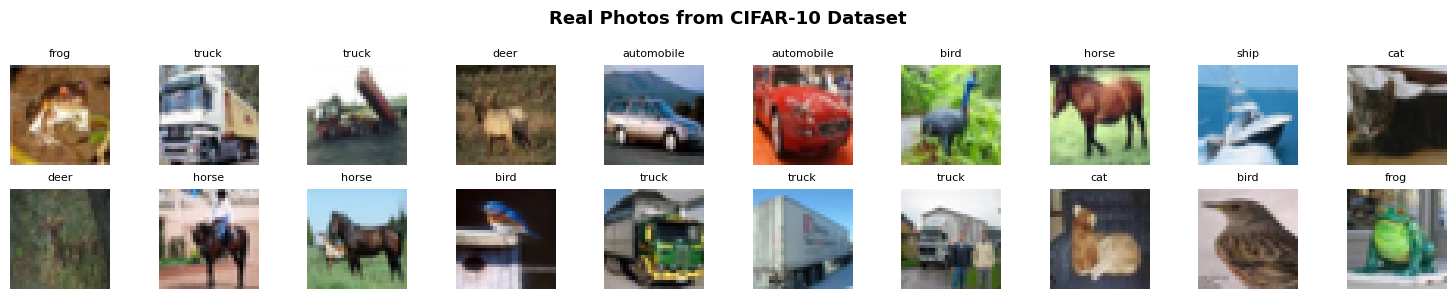

In [3]:
# Show sample images from the dataset so students can see what we are working with
fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    # Top row — training images
    axes[0, i].imshow(x_train[i])
    axes[0, i].set_title(class_names[y_train[i][0]], fontsize=8)
    axes[0, i].axis('off')

    # Bottom row — more samples of same classes
    axes[1, i].imshow(x_train[i + 10])
    axes[1, i].set_title(class_names[y_train[i+10][0]], fontsize=8)
    axes[1, i].axis('off')

plt.suptitle("Real Photos from CIFAR-10 Dataset", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## How Computers See Images

To a computer, every image is just a **grid of numbers**.  
Each number is a pixel value between **0 (black)** and **255 (white)**.  
A colour image has **3 grids stacked** — one each for Red, Green, Blue (RGB).

In [4]:
# Pick one image and look at what the computer actually sees
sample_image = x_train[0]

print("Image label (what it is)  :", class_names[y_train[0][0]])
print("Image shape               :", sample_image.shape)
print("  → Height   :", sample_image.shape[0], "pixels")
print("  → Width    :", sample_image.shape[1], "pixels")
print("  → Channels :", sample_image.shape[2], "(Red, Green, Blue)")
print()

# Show the actual numbers the computer sees for the Red channel
print("Red channel — top-left 6×6 corner (numbers the computer sees):")
print(sample_image[:6, :6, 0])  # rows 0-5, columns 0-5, channel 0 = Red

Image label (what it is)  : frog
Image shape               : (32, 32, 3)
  → Height   : 32 pixels
  → Width    : 32 pixels
  → Channels : 3 (Red, Green, Blue)

Red channel — top-left 6×6 corner (numbers the computer sees):
[[ 59  43  50  68  98 119]
 [ 16   0  18  51  88 120]
 [ 25  16  49  83 110 129]
 [ 33  38  87 106 115 117]
 [ 50  59 102 127 124 121]
 [ 71  84 110 129 136 131]]


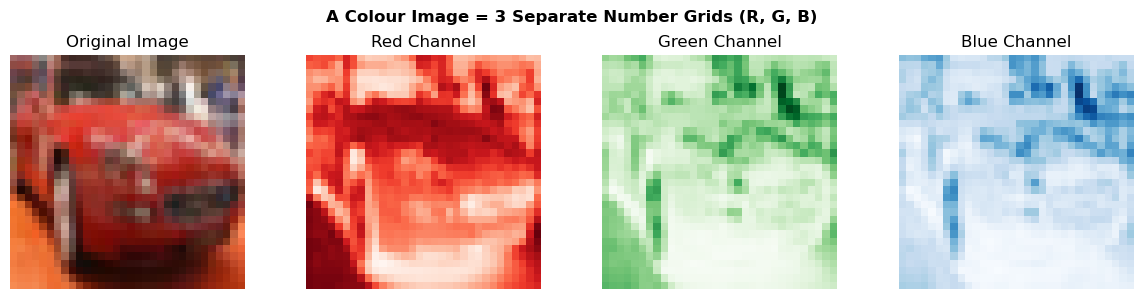

In [5]:
# Visualise the 3 colour channels separately
sample_image = x_train[5]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Original colour image
axes[0].imshow(sample_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Each channel separately
for i, (name, cmap) in enumerate(zip(['Red','Green','Blue'], ['Reds','Greens','Blues'])):
    axes[i+1].imshow(sample_image[:, :, i], cmap=cmap)
    axes[i+1].set_title(f"{name} Channel")
    axes[i+1].axis('off')

plt.suptitle("A Colour Image = 3 Separate Number Grids (R, G, B)", fontweight='bold')
plt.tight_layout()
plt.show()

## What is a CNN and How Does it Work?

A **Convolutional Neural Network (CNN)** learns to recognise images by:
1. **Convolution** — a small filter slides over the image and detects patterns like edges
2. **Pooling** — shrinks the image to keep only the most important information
3. **Fully Connected layers** — uses what was learned to make the final prediction

Each layer learns more complex features:
- Layer 1 → edges and colours
- Layer 2 → shapes and textures
- Layer 3+ → object parts and whole objects

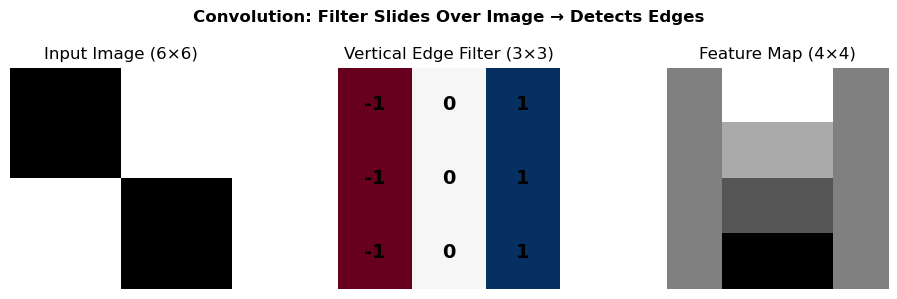

Formula: output size = input size − filter size + 1
         = 6 − 3 + 1 = 4


In [6]:
# Show the convolution operation from scratch so students understand it
# A filter is a small matrix that slides over the image

# Simple 6x6 image (1 = white, 0 = black)
image = np.array([
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 0],
    [1, 1, 1, 0, 0, 0],
    [1, 1, 1, 0, 0, 0]
], dtype=float)

# Vertical edge filter — detects vertical lines in the image
filter_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=float)

# Apply the filter manually — slide it over the image
out_size = 6 - 3 + 1  # input size - filter size + 1 = 4
feature_map = np.zeros((out_size, out_size))

for i in range(out_size):
    for j in range(out_size):
        # Multiply filter values with image patch and sum
        patch            = image[i:i+3, j:j+3]
        feature_map[i,j] = np.sum(patch * filter_vertical)

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Input Image (6×6)")
axes[0].axis('off')

axes[1].imshow(filter_vertical, cmap='RdBu')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, int(filter_vertical[i,j]),
                     ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].set_title("Vertical Edge Filter (3×3)")
axes[1].axis('off')

axes[2].imshow(feature_map, cmap='gray')
axes[2].set_title(f"Feature Map ({out_size}×{out_size})")
axes[2].axis('off')

plt.suptitle("Convolution: Filter Slides Over Image → Detects Edges", fontweight='bold')
plt.tight_layout()
plt.show()

print("Formula: output size = input size − filter size + 1")
print(f"         = 6 − 3 + 1 = {out_size}")

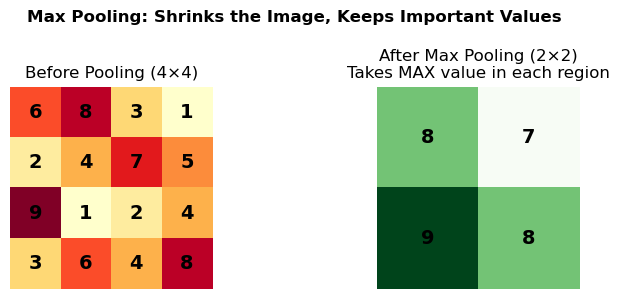

4×4 → 2×2 means 75% size reduction
Benefit: fewer parameters, faster training, less overfitting


In [7]:
# Show Max Pooling — reduces image size, keeps strongest values

before_pooling = np.array([
    [6, 8, 3, 1],
    [2, 4, 7, 5],
    [9, 1, 2, 4],
    [3, 6, 4, 8]
], dtype=float)

# 2×2 Max Pooling — take the maximum value from each 2×2 region
after_pooling = np.array([
    [max(6,8,2,4),  max(3,1,7,5)],   # top-left and top-right regions
    [max(9,1,3,6),  max(2,4,4,8)]    # bottom-left and bottom-right regions
], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(before_pooling, cmap='YlOrRd')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, int(before_pooling[i,j]),
                     ha='center', va='center', fontsize=14, fontweight='bold')
axes[0].set_title("Before Pooling (4×4)")
axes[0].axis('off')

axes[1].imshow(after_pooling, cmap='Greens')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, int(after_pooling[i,j]),
                     ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].set_title("After Max Pooling (2×2)\nTakes MAX value in each region")
axes[1].axis('off')

plt.suptitle("Max Pooling: Shrinks the Image, Keeps Important Values", fontweight='bold')
plt.tight_layout()
plt.show()

print("4×4 → 2×2 means 75% size reduction")
print("Benefit: fewer parameters, faster training, less overfitting")

## Preprocess the Data
Before training we must:
1. **Normalise** pixel values from 0–255 down to 0–1 (makes training stable)
2. **One-hot encode** labels (required for the softmax output layer)

In [8]:
# -------------------------------------------------------
# PREPROCESS THE DATA
# -------------------------------------------------------

# MEMORY FIX: we normalise in-place instead of creating a new array
# this avoids doubling the memory usage

# convert to float32 and normalise — done in one step to save memory
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# free up the original arrays from memory since we no longer need them
# this is important when RAM is limited
import gc
del x_train, x_test
gc.collect()

# one-hot encode labels
# example: class 3 (cat) becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print("Normalisation done — pixel range:", x_train_norm.min(), "to", x_train_norm.max())
print("Label before one-hot encoding:", y_train[0])
print("Label after  one-hot encoding:", y_train_cat[0])

Normalisation done — pixel range: 0.0 to 1.0
Label before one-hot encoding: [6]
Label after  one-hot encoding: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## Build the CNN

In [9]:
# Build the CNN architecture using Keras Sequential API
model = models.Sequential([

    # Block 1 — learn simple features: edges and colours
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Block 2 — learn more complex features: shapes and textures
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 3 — learn high-level features: object parts
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),

    # Flatten — convert 3D feature maps into a 1D vector for the Dense layers
    layers.Flatten(),

    # Dense layer — combine all learned features to make a decision
    layers.Dense(64, activation='relu'),

    # Dropout — randomly switch off 50% of neurons to prevent overfitting
    layers.Dropout(0.5),

    # Output layer — 10 neurons, one per class, softmax gives probabilities
    layers.Dense(10, activation='softmax')
])

# Compile — set the learning algorithm, loss function, and metric to track
model.compile(
    optimizer='adam',                   # adam adjusts learning rate automatically
    loss='categorical_crossentropy',    # standard loss for multi-class problems
    metrics=['accuracy']
)

model.summary()

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         262,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the CNN
# validation_split=0.1 means 10% of training data is used to monitor progress

history = model.fit(
    x_train_norm, y_train_cat,
    epochs           = 10,        # how many times to go through the full dataset
    batch_size       = 64,        # how many images to process at once
    validation_split = 0.1,
    verbose          = 1
)

print("\nTraining complete!")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.3654 - loss: 1.7317 - val_accuracy: 0.5244 - val_loss: 1.3296
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.5036 - loss: 1.3894 - val_accuracy: 0.5594 - val_loss: 1.2311
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5616 - loss: 1.2364 - val_accuracy: 0.6158 - val_loss: 1.1219
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6037 - loss: 1.1209 - val_accuracy: 0.6716 - val_loss: 0.9518
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6348 - loss: 1.0378 - val_accuracy: 0.7068 - val_loss: 0.8486
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6621 - loss: 0.9625 - val_accuracy: 0.7040 - val_loss: 0.8577
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6812 - loss: 0.9028 - val_accuracy: 0.7094 - val_loss: 0.8333
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6980 - loss: 0.8565 - 

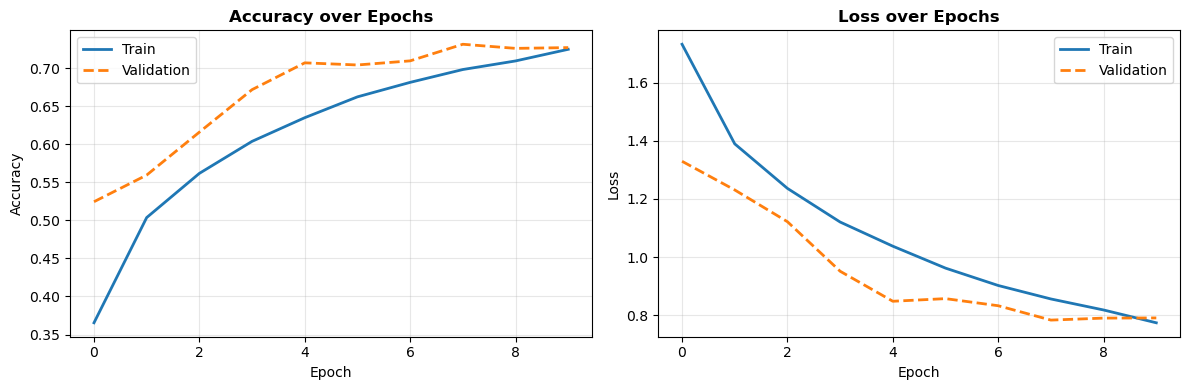

Test Accuracy : 71.62%
Test Loss     : 0.8258


In [11]:
# Plot accuracy and loss curves to understand how training went
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy — we want this to go UP
axes[0].plot(history.history['accuracy'],     label='Train',      linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss — we want this to go DOWN
axes[1].plot(history.history['loss'],     label='Train',      linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on the test set — data the model has NEVER seen before
test_loss, test_acc = model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

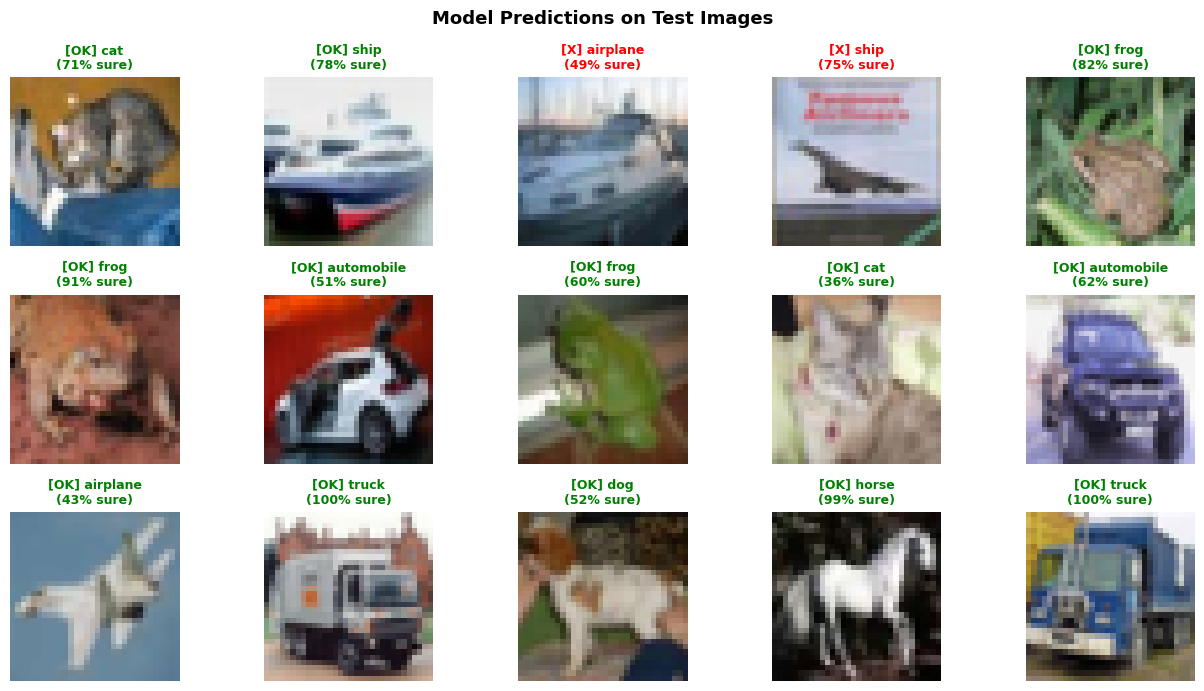

In [16]:
# Step 6: See what the model predicts on real images

predictions = model.predict(x_test_norm[:15], verbose=0)

fig, axes = plt.subplots(3, 5, figsize=(13, 7))
axes      = axes.flatten()

for i, ax in enumerate(axes):
    display_img = (x_test_norm[i] * 255).astype('uint8')
    ax.imshow(display_img)

    true_label = class_names[y_test[i][0]]
    pred_label = class_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100
    correct    = true_label == pred_label
    color      = 'green' if correct else 'red'
    mark       = '[OK]' if correct else '[X]'

    ax.set_title(f"{mark} {pred_label}\n({confidence:.0f}% sure)",
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle("Model Predictions on Test Images", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Part 6 — Data Augmentation
When your dataset is small, **augmentation** creates new training examples  
by applying random transformations to existing images.  
This helps the model generalise better and reduces overfitting.

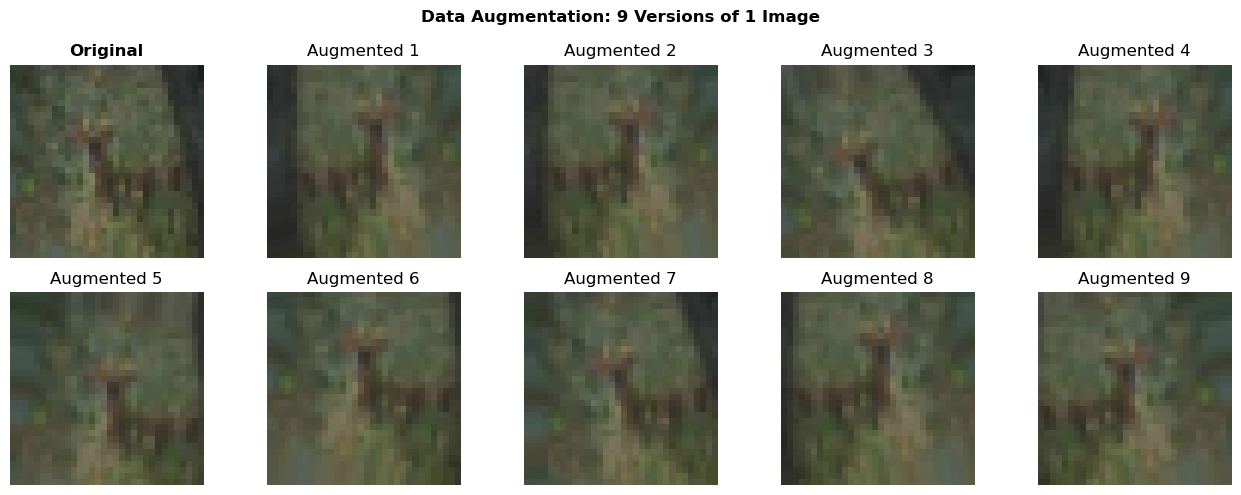

All 9 images came from 1 original image!


In [19]:
# Show what data augmentation looks like

datagen = ImageDataGenerator(
    horizontal_flip    = True,
    rotation_range     = 15,
    zoom_range         = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1
)

base_img = np.expand_dims((x_train_norm[10] * 255).astype(np.uint8), 0)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
axes      = axes.flatten()

axes[0].imshow((x_train_norm[10] * 255).astype(np.uint8))
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

for i in range(1, 10):
    aug_img = next(datagen.flow(base_img, batch_size=1))[0].astype(np.uint8)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')

plt.suptitle("Data Augmentation: 9 Versions of 1 Image", fontweight='bold')
plt.tight_layout()
plt.show()

print("All 9 images came from 1 original image!")
#print("Augmentation gives the model more variety to learn from.")

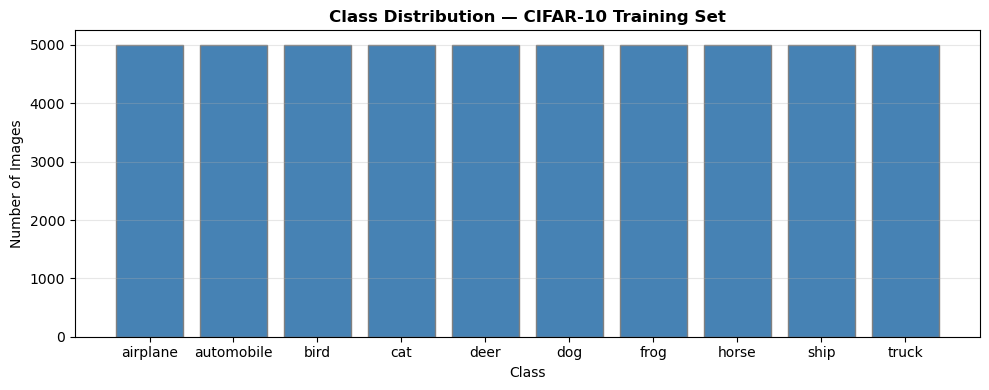

Class counts:
  airplane     : 5,000 images
  automobile   : 5,000 images
  bird         : 5,000 images
  cat          : 5,000 images
  deer         : 5,000 images
  dog          : 5,000 images
  frog         : 5,000 images
  horse        : 5,000 images
  ship         : 5,000 images
  truck        : 5,000 images

CIFAR-10 is balanced — 5,000 images per class.


In [20]:
# Always check class balance before training your own dataset
# Here we do it for CIFAR-10 as an example

counts = np.bincount(y_train.flatten())

plt.figure(figsize=(10, 4))
plt.bar(class_names, counts, color='steelblue', edgecolor='gray')
plt.title("Class Distribution — CIFAR-10 Training Set", fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Class counts:")
for name, count in zip(class_names, counts):
    print(f"  {name:<12} : {count:,} images")

print("\nCIFAR-10 is balanced — 5,000 images per class.")
#print("In real Nigerian datasets this is often NOT the case — always check!")